In [1]:
req.libs <- c("data.table", "dplyr", "ggplot2", "scattermore", 
              "stringi", "tidyr", "viridis", "Matrix", "tibble", "ComplexHeatmap", "circlize", "stringr", "Biostrings")
lapply(req.libs, function(x){
    suppressMessages(library(x, character.only = TRUE))})

[[1]]
[1] "data.table" "stats"      "graphics"   "grDevices"  "utils"     
[6] "datasets"   "methods"    "base"      

[[2]]
[1] "dplyr"      "data.table" "stats"      "graphics"   "grDevices" 
[6] "utils"      "datasets"   "methods"    "base"      

[[3]]
 [1] "ggplot2"    "dplyr"      "data.table" "stats"      "graphics"  
 [6] "grDevices"  "utils"      "datasets"   "methods"    "base"      

[[4]]
 [1] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
 [6] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[11] "base"       

[[5]]
 [1] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
 [6] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[11] "methods"     "base"       

[[6]]
 [1] "tidyr"       "stringi"     "scattermore" "ggplot2"     "dplyr"      
 [6] "data.table"  "stats"       "graphics"    "grDevices"   "utils"      
[11] "datasets"    "methods"     "base"       

[[7]]
 [1] "viridis"     "viridisLite" "tidyr"       "stringi"     "scattermore"
 [6] "ggplot2"     "dplyr"       "data.table"  "stats"       "graphics"   
[11] "grDevices"   "utils"       "datasets"    "methods"     "base"       

[[8]]
 [1] "Matrix"      "viridis"     "viridisLite" "tidyr"       "stringi"    
 [6] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
[11] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[16] "base"       

[[9]]
 [1] "tibble"      "Matrix"      "viridis"     "viridisLite" "tidyr"      
 [6] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
[11] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[16] "methods"     "base"       

[[10]]
 [1] "ComplexHeatmap" "grid"           "tibble"         "Matrix"        
 [5] "viridis"        "viridisLite"    "tidyr"          "stringi"       
 [9] "scattermore"    "ggplot2"        "dplyr"          "data.table"    
[13] "stats"          "graphics"       "grDevices"      "utils"         
[17] "datasets"       "methods"        "base"          

[[11]]
 [1] "circlize"       "ComplexHeatmap" "grid"           "tibble"        
 [5] "Matrix"         "viridis"        "viridisLite"    "tidyr"         
 [9] "stringi"        "scattermore"    "ggplot2"        "dplyr"         
[13] "data.table"     "stats"          "graphics"       "grDevices"     
[17] "utils"          "datasets"       "methods"        "base"          

[[12]]
 [1] "stringr"        "circlize"       "ComplexHeatmap" "grid"          
 [5] "tibble"         "Matrix"         "viridis"        "viridisLite"   
 [9] "tidyr"          "stringi"        "scattermore"    "ggplot2"       
[13] "dplyr"          "data.table"     "stats"          "graphics"      
[17] "grDevices"      "utils"          "datasets"       "methods"       
[21] "base"          

[[13]]
 [1] "Biostrings"     "GenomeInfoDb"   "XVector"        "IRanges"       
 [5] "S4Vectors"      "stats4"         "BiocGenerics"   "stringr"       
 [9] "circlize"       "ComplexHeatmap" "grid"           "tibble"        
[13] "Matrix"         "viridis"        "viridisLite"    "tidyr"         
[17] "stringi"        "scattermore"    "ggplot2"        "dplyr"         
[21] "data.table"     "stats"          "graphics"       "grDevices"     
[25] "utils"          "datasets"       "methods"        "base"

In [3]:
meta <- fread("/mnt/users/rachelsavage/paper_minimorf/data/initial_filtering/atac.filtered.metadata.tsv")
donor <- fread("/mnt/users/rachelsavage/paper_minimorf/data/donor_calling/filt.donor.txt")
tf <- fread("/mnt/users/rachelsavage/paper_minimorf/data/barcode_calling/tf_calls/tf.metadata.csv")

In [4]:
barcode.df <- meta %>% dplyr::select(barcode) %>%
  mutate(
    round1 = str_sub(barcode, 1, 8),
    round2 = str_sub(barcode, 9, 16),
    round3 = str_sub(barcode, 17, 24)
  )

In [5]:
plate <- fread("/mnt/users/rachelsavage/paper_minimorf/data/reference_data/shareseq_plate_barcodes.csv")
plate <- plate %>% filter(grepl("R3", `Plate Name`))

In [6]:
plate$Sequence <- gsub(" ", "", plate$Sequence)
#plate$constantleft <- str_sub(plate$Sequence,1, 24)
plate$barcode <- str_sub(plate$Sequence,25, 32)
#plate$constantright <- str_sub(plate$Sequence,33, 47)
plate$barcode.rc <- as.character(reverseComplement(DNAStringSet(plate$barcode)))
# (unique(plate$constantright))
# (unique(plate$constantleft))
# dim(plate)
# length(unique(plate$barcode))
head(plate)

Plate Name,Well Position,Sequence,barcode,barcode.rc
<chr>,<chr>,<chr>,<chr>,<chr>
SHARE_seq_Plate_R3,A01,CAAGCAGAAGACGGCATACGAGATAACGTGATGTGGCCGATGTTTCG,AACGTGAT,ATCACGTT
SHARE_seq_Plate_R3,A02,CAAGCAGAAGACGGCATACGAGATCGCTGATCGTGGCCGATGTTTCG,CGCTGATC,GATCAGCG
SHARE_seq_Plate_R3,A03,CAAGCAGAAGACGGCATACGAGATAAGGTACAGTGGCCGATGTTTCG,AAGGTACA,TGTACCTT
SHARE_seq_Plate_R3,A04,CAAGCAGAAGACGGCATACGAGATAGATCGCAGTGGCCGATGTTTCG,AGATCGCA,TGCGATCT
SHARE_seq_Plate_R3,A05,CAAGCAGAAGACGGCATACGAGATCACTTCGAGTGGCCGATGTTTCG,CACTTCGA,TCGAAGTG
SHARE_seq_Plate_R3,A06,CAAGCAGAAGACGGCATACGAGATCGACTGGAGTGGCCGATGTTTCG,CGACTGGA,TCCAGTCG


In [7]:
plate <- plate %>% mutate(plate = ifelse(`Plate Name` == "SHARE_seq_Plate_R3", "Plate1", "Plate2")) %>%
mutate(well = `Well Position`)%>%
dplyr::select(plate, well, barcode.rc)
tail(plate)

plate,well,barcode.rc
<chr>,<chr>,<chr>
Plate2,H07,CGCGCAAC
Plate2,H08,CAATTCGT
Plate2,H09,AGCATACG
Plate2,H10,CTGCAGAT
Plate2,H11,GGTGCTAC
Plate2,H12,GTGTAGTG


In [8]:
yield <- barcode.df %>% left_join(plate, by = c("round1" = "barcode.rc"))
table(yield$plate)


Plate1 
762374 

In [9]:
mx <- yield %>% 
filter(plate == "Plate1")%>%
group_by(plate, well) %>% 
summarize(n.cells = n())%>%
mutate(row = str_sub(well, 1,1),
       column = paste0("col_",  str_sub(well, 2,3))) %>% ungroup()%>%
mutate(log.n.cells = log10(n.cells))%>%
dplyr::select(row, column, log.n.cells)%>%
pivot_wider(names_from = column, values_from = log.n.cells)%>%
column_to_rownames("row")%>%
as.matrix()

`summarise()` has grouped output by 'plate'. You can override using the
`.groups` argument.


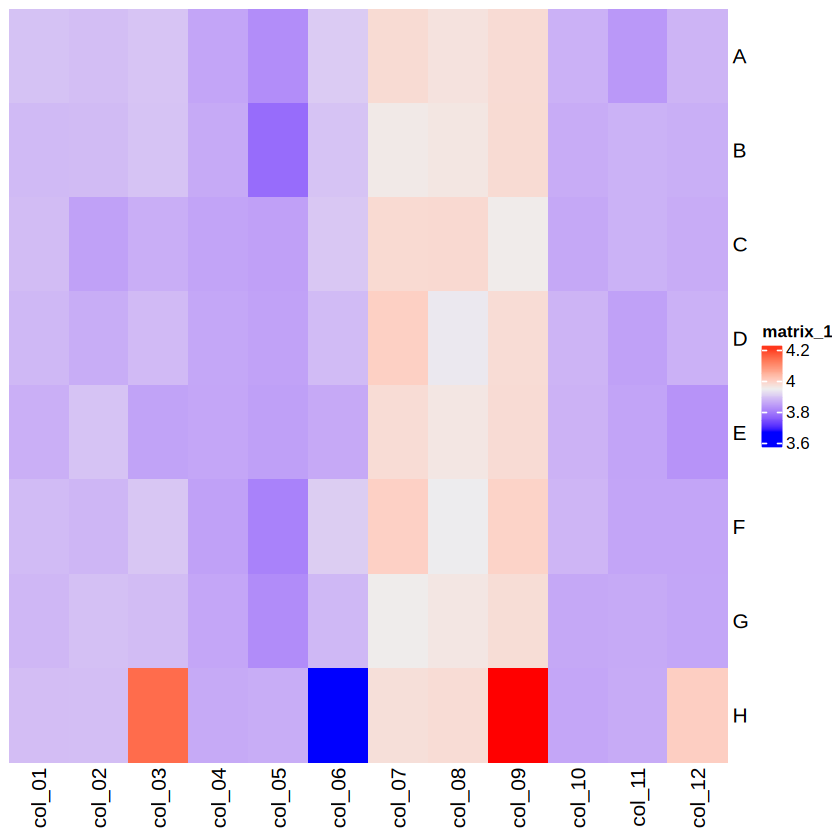

In [10]:
Heatmap(mx, cluster_columns = FALSE, 
        cluster_rows = FALSE)

In [11]:
condition <- barcode.df %>% left_join(plate, by = c("round1" = "barcode.rc")) %>%
mutate(row = str_sub(well, 1,1),
       column = as.numeric(str_sub(well, 2,3))) %>% ungroup()



In [12]:
sample.mapping <- data.frame(
    column = 1:12,
    condition = c(rep("a.acute_unstim", 3), rep("b.acute_stim", 3), rep("c.exhausted_unstim", 3), rep("d.exhausted_stim", 3)))
sample.mapping

column,condition
<int>,<chr>
1,a.acute_unstim
2,a.acute_unstim
3,a.acute_unstim
4,b.acute_stim
5,b.acute_stim
6,b.acute_stim
7,c.exhausted_unstim
8,c.exhausted_unstim
9,c.exhausted_unstim


In [13]:
condition <- condition %>% left_join(sample.mapping) %>% dplyr::select(barcode, condition)

Joining with `by = join_by(column)`


In [18]:
head(donor)

cell,num_snps,num_umis,ratio,pvalue,FDR_pvalue,bestLikelihood,bestSample,median_likelihood,population_average_likelihood,donor1,donor2,donor3,doublet
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
GCAATCCGTGTACCTTGTTAGCCT_SS-PKR-608,82,96,5.7634,1.7242e-06,1.9379e-06,-69.5690,donor3,-75.332,-45.457,-116.340,-75.332,-69.5690,no
GTGTGTCGGAGCCAATTATGCCAG_SS-PKR-608,102,118,47.1660,6.8208e-48,3.3551e-47,-72.6180,donor1,-119.780,-52.717,-72.618,-123.550,-119.7800,no
TATGTGGCTGTGGTTGGATAGAGG_SS-PKR-608,39,49,40.7110,1.9469e-41,7.3117e-41,-9.4363,donor3,-50.147,-14.629,-53.726,-50.147,-9.4363,no
GAATCTGTTTGACTCTGTACATCT_SS-PKR-608,201,247,130.0900,8.1072e-131,1.8113e-128,-56.3780,donor3,-186.470,-56.725,-222.070,-186.470,-56.3780,no
CTTGTACTTATGTGGCGGAATGAT_SS-PKR-608,64,67,34.1860,6.5169e-35,1.8564e-34,-22.2720,donor1,-56.458,-20.520,-22.272,-65.545,-56.4580,no
GAGCCAATGCTCCTTGTGGCTCAG_SS-PKR-608,77,85,49.8410,1.4412e-50,7.9316e-50,-24.7610,donor3,-74.602,-20.946,-83.681,-74.602,-24.7610,no


In [19]:
donor.df <- donor %>% dplyr::select(cell, bestSample, doublet)
colnames(donor.df) <- c("barcode", "donor", "doublet")

meta.filt <- meta %>% dplyr::select(barcode, total.mapped.reads, unique.mapped.reads, libsize, sublibrary,FRIP)
colnames(meta.filt) <- c("barcode", "ATAC_total_mapped_reads", "ATAC_unique_mapped_reads", "ATAC_libsize", "sublibrary", "FRIP")

In [20]:
###join everything together 
meta.df <- meta.filt %>% 
left_join(condition, by = "barcode") %>%
left_join(tf[,c("barcode", "n.tfs", "final.tf")], by = "barcode")%>%
left_join(donor.df, by = "barcode") %>%
mutate(n.tfs = replace_na(n.tfs, 0))

In [23]:
meta.df.dedub <- meta.df %>% filter(doublet != "yes")
dim(meta.df.dedub)
dim(meta.df)

[1] 702314     11

[1] 762374     11

In [ ]:
fwrite(meta.df, "/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/meta.csv")
fwrite(meta.df.dedub, "/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/meta.dedoublet.csv")

In [ ]:
##just a note in hindsight. the dedub is also the metadata where each cell has a donor assinged. so its overly stringent filtering. 